# Full EDA — Enterprise E-Commerce Predictive Analytics

This notebook consolidates the exploratory data analysis for all six Power BI dashboard pages into a single file. Each section is clearly separated and corresponds to one dashboard, covering everything from high-level sales KPIs to granular marketing efficiency, refund leakage, and promotional impact analysis.

**Sections covered:**
1. Sales Overview (Dashboard 1)
2. Product-Level Performance EDA (Dashboard 2)
3. Revenue & Marketplace Trends (Dashboard 3)
4. Marketing & PPC Analysis (Dashboard 4)
5. Refund Leakage & Quality Control (Dashboard 5)
6. Promotions & Returns Analysis (Dashboard 6)

---

## Section 0 — Setup & Data Loading

Load the fully joined **Star Schema** table produced by the Gold Layer notebook. The Gold Layer already performs all dimension-fact joins (fact_sales + dim_date + dim_product + dim_marketplace) and exports the result to `Star Schema.xlsx`. No further joining is required here.

**Path configuration:**
- Local (cloned repo): `../../Medallion Architecture/Gold Layer/Star Schema.xlsx`
- Google Colab: upload the file and use `/content/Star Schema.xlsx`


In [ ]:
#  Libraries
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("plotly not installed — plotly charts will be skipped.")

warnings.filterwarnings("ignore")
sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (12, 5)
pd.options.display.float_format = "{:,.2f}".format
print('Libraries loaded.')


In [ ]:
#  Load pre-joined Star Schema from Gold Layer output
# The Gold Layer produces Star Schema.xlsx with a Star_Schema sheet that
# is already the fully denormalized fact + all dimensions joined table.
# We load it directly — no merging needed in this notebook.

LOCAL_STAR_SCHEMA = r'../../Medallion Architecture/Gold Layer/Star Schema.xlsx'
COLAB_STAR_SCHEMA = '/content/Star Schema.xlsx'

import os

if os.path.exists(LOCAL_STAR_SCHEMA):
    _src = LOCAL_STAR_SCHEMA
    print(f'Loading from local: {_src}')
elif os.path.exists(COLAB_STAR_SCHEMA):
    _src = COLAB_STAR_SCHEMA
    print(f'Loading from Colab: {_src}')
else:
    raise FileNotFoundError(
        'Star Schema.xlsx not found. Run the Gold Layer notebook first to generate it, '
        'then upload it here or ensure the repo is cloned locally.'
    )

df = pd.read_excel(_src, sheet_name='Star_Schema')

# Convenience alias (used in Dashboard 5 section)
sales = df

print(f'Loaded Star_Schema: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)


> `df` is now ready for use across all sections below. It is the fully denormalized Star Schema table — fact_sales joined with dim_date, dim_product, and dim_marketplace — as produced and exported by the Gold Layer notebook.


---

## Dashboard 1 — Sales Overview

This section covers the top-level business performance metrics. It reproduces the KPI cards and trend charts from Power BI Page 1, including total revenue, total orders, units sold, net profit, average refund rate, and marketplace-level breakdowns.


### Libraries & Configuration
Load all required libraries and configure display settings.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

ModuleNotFoundError: No module named 'plotly'

### Data Source


> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


### Dashboard 1 Overview

This section calculates and displays the nine core KPIs for the Sales Overview page:

| KPI | Description |
|---|---|
| Total Revenue | Sum of all revenue across all marketplaces and periods |
| Total Orders | Total number of customer orders placed |
| Total Units Sold | Aggregate units shipped |
| Total Net Profit | Revenue minus all costs (COGS, FBA, PPC, Taxes) |
| Blended Net Margin | Weighted average net margin across the full portfolio |
| Average Net ROI | Mean return on investment per row |
| Total PPC Cost | Total advertising spend across all campaigns |
| Total TACoS | Total Advertising Cost of Sales — PPC Cost / Total Revenue |
| Average Net ROI | Mean ROI after all costs |

These KPIs are followed by seven analytical charts.


### KPI Calculations


#### KPI — Total Revenue


In [ ]:
total_revenue = fact_sales['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 3628133.7699999996


#### KPI — Total Orders


In [ ]:
total_orders = fact_sales['Orders'].sum()
print("Total Orders:", total_orders)

Total Orders: 151164


#### KPI — Total Units Sold


In [ ]:
total_units = fact_sales['Units'].sum()
print("Total Units Sold:", total_units)

Total Units Sold: 177177


#### KPI — Total Net Profit


In [ ]:
total_net_profit = fact_sales['Net Profit'].sum()
print("Total Net Profit:", total_net_profit)

Total Net Profit: 815690.23


#### KPI — Total PPC Cost


In [ ]:
total_ppc_cost = fact_sales['PPC Cost'].sum()
print("Total PPC Cost:", total_ppc_cost)

Total PPC Cost: -203132.78


#### KPI — Total Net ROI


In [ ]:
total_net_roi = fact_sales['Net ROI'].sum()
print("Total Net ROI:", total_net_roi)

Total Net ROI: 3920.8005999999996


#### KPI — Average Net ROI


In [ ]:
avg_net_roi = fact_sales['Net ROI'].mean()
print("Average Net ROI:", avg_net_roi)

Average Net ROI: 0.294288118291676


#### KPI — Blended Net Margin


In [ ]:
blended_net_margin = total_net_profit / total_revenue
print("Blended Net Margin:", blended_net_margin)

Blended Net Margin: 0.22482363708436254


#### KPI — Total TACoS (Total Advertising Cost of Sales)


In [ ]:
total_tacos = abs(total_ppc_cost) / total_revenue
print("Total Tacos:", total_tacos)

Total Tacos: 0.055988227798998716


### Charts


#### Chart 1 — True Profitability Trend (Combo Chart)

Overlay Revenue and Net Profit on a monthly time axis to visualize the spread between top-line growth and actual bottom-line performance. Diverging trends signal increasing cost pressure.


In [ ]:
import plotly.graph_objects as go

# 'Date' column is already in datetime format from AOaOuShhNGe7

# Create 'Month_Year' column
df_merged['Month_Year'] = df_merged['Year'].astype(str) + '-' + df_merged['Month_Name']

# Sort the DataFrame by 'Date' to ensure correct chronological order for plotting
df_merged = df_merged.sort_values(by='Date')

# Prepare monthly data
monthly_data = df_merged.groupby('Month_Year', sort=False)[['Revenue', 'Net Profit']].sum().reset_index()

# Create bar trace for Revenue
bar_trace = go.Bar(
    x=monthly_data['Month_Year'],
    y=monthly_data['Revenue'],
    name='Total Revenue',
    marker_color='skyblue'
)

# Create line trace for Net Profit
line_trace = go.Scatter(
    x=monthly_data['Month_Year'],
    y=monthly_data['Net Profit'],
    mode='lines+markers',
    name='Net Profit',
    yaxis='y2',
    marker_color='red'
)

# Create figure with secondary y-axis
fig = go.Figure(data=[bar_trace, line_trace])

# Add titles and labels
fig.update_layout(
    title_text='True Profitability Trend: Revenue vs Net Profit',
    xaxis_title='Month and Year',
    yaxis_title='Total Revenue',
    yaxis2=dict(
        title='Net Profit',
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
)

fig.show()

#### Chart 2 — Order & Unit Trajectory (Dual Line Chart)

Track total orders and units sold over time on dual axes. A widening gap between the two lines indicates a rising units-per-order ratio, while a narrowing gap may signal more single-unit transactions.


In [ ]:
import plotly.graph_objects as go

daily_trajectory = df_merged.groupby('Date')[['Orders', 'Units']].sum().reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_trajectory['Date'],
    y=daily_trajectory['Orders'],
    mode='lines+markers',
    name='Orders'
))

fig.add_trace(go.Scatter(
    x=daily_trajectory['Date'],
    y=daily_trajectory['Units'],
    mode='lines',
    name='Units Sold',
    line=dict(dash='dash')
))

fig.update_layout(
    title='Order & Unit Trajectory',
    xaxis_title='Date',
    yaxis_title='Count',
    hovermode='x unified'
)

fig.show()

#### Chart 3 — Average Order Value per Month

Calculate monthly average order value (Revenue / Orders). Declining AOV may reflect promotional pressure or product-mix shift toward lower-ticket items.


In [ ]:
# Calculate monthly revenue and orders
monthly_aov_data = df_merged.groupby('Month_Year', sort=False).agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('Orders', 'sum')
).reset_index()

# Calculate Average Order Value (AOV)
monthly_aov_data['Average Order Value'] = monthly_aov_data['total_revenue'] / monthly_aov_data['total_orders']

display(monthly_aov_data[['Month_Year', 'Average Order Value']])

# Plotting the Average Order Value trend using Plotly
fig = px.line(
    monthly_aov_data,
    x='Month_Year',
    y='Average Order Value',
    title='Average Order Value Trend Per Month',
    markers=True,
    color_discrete_sequence=['purple']
)

fig.update_layout(
    xaxis_title='Month and Year',
    yaxis_title='Average Order Value',
    xaxis_tickangle=-45,
    hovermode='x unified'
)

fig.show()

,Month_Year,Average Order Value
0,2020-October,24.657366
1,2020-November,24.550804
2,2020-December,24.854247
3,2021-January,23.398763
4,2021-February,23.037921
5,2021-March,23.375527
6,2021-April,24.419615


#### Chart 4 — TACoS vs. Net Margin (Dual-Axis Line Chart)

Plot Total Advertising Cost of Sales (TACoS = PPC Cost / Revenue) alongside Net Margin % over time. When TACoS rises and Net Margin falls in tandem, PPC spend is eroding profitability.


In [ ]:
import plotly.graph_objects as go

# Calculate monthly percentages
# Handle division by zero for Revenue to avoid 'inf' values
df_merged['TACoS'] = np.where(df_merged['Revenue'] != 0, abs(df_merged['PPC Cost']) / df_merged['Revenue'], 0)
df_merged['Net_Margin_Pct'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

monthly_tacos = df_merged.groupby('Month_Year', sort=False)[['TACoS', 'Net_Margin_Pct']].mean().reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_tacos['Month_Year'],
    y=monthly_tacos['TACoS'],
    mode='lines+markers',
    name='TACoS %',
    marker_color='blue'
))

fig.add_trace(go.Scatter(
    x=monthly_tacos['Month_Year'],
    y=monthly_tacos['Net_Margin_Pct'],
    mode='lines+markers',
    name='Net Margin %',
    marker_color='green'
))

fig.update_layout(
    title='TACoS vs Net Margin Trend',
    xaxis_title='Month and Year',
    yaxis_title='Percentage',
    xaxis_tickangle=-45,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)'),
    hovermode='x unified'
)

fig.show()

#### Chart 5 — Net Margin % per Marketplace

Compare blended net margin across all Amazon marketplace accounts. Identifies which regions deliver the highest margin after local taxes, fees, and ad spend.


In [ ]:
# Calculate Net Margin Percentage for each row, handling division by zero
df_merged['Net_Margin_Pct_Marketplace'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

# Group by 'Market Place' and calculate the mean of 'Net_Margin_Pct_Marketplace'
net_margin_by_marketplace = df_merged.groupby('Market Place')['Net_Margin_Pct_Marketplace'].mean().reset_index()

display(net_margin_by_marketplace)

,Market Place,Net_Margin_Pct_Marketplace
0,DE,0.243986
1,ES,0.204599
2,FR,0.122173
3,IT,0.111746
4,UK,0.131384


In [ ]:
import plotly.express as px

# Calculate Net Margin Percentage for each row, handling division by zero
df_merged['Net_Margin_Pct_Marketplace'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

# Group by 'Market Place' and calculate the mean of 'Net_Margin_Pct_Marketplace'
net_margin_by_marketplace = df_merged.groupby('Market Place')['Net_Margin_Pct_Marketplace'].mean().reset_index()

# Plotting with Plotly Express
fig = px.bar(
    net_margin_by_marketplace,
    x='Market Place',
    y='Net_Margin_Pct_Marketplace',
    title='Net Margin Percentage Across Marketplaces',
    color='Market Place',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Market Place',
    yaxis_title='Net Margin Percentage',
    yaxis_range=[0, net_margin_by_marketplace['Net_Margin_Pct_Marketplace'].max() * 1.1] # Set y-axis limit slightly above max for better visualization
)

fig.show()

#### Chart 6 — Cost Structure Waterfall Analysis

Break down aggregate revenue into its constituent cost components — COGS, FBA Fees, PPC Cost, Taxes — and show what remains as Net Profit. The waterfall format makes margin erosion visually immediate.


In [ ]:
import plotly.express as px

# Aggregate costs
costs = ['COGS', 'FBA Fees', 'Taxes', 'PPC Cost']
values = [abs(df_merged[c].sum()) for c in costs]

# Create a DataFrame for Plotly
cost_df = pd.DataFrame({'Cost Type': costs, 'Amount': values})

# Plotting with Plotly Express
fig = px.bar(
    cost_df,
    x='Cost Type',
    y='Amount',
    title='Cost Structure Analysis',
    color='Cost Type',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Cost Type',
    yaxis_title='Amount'
)

fig.show()

#### Chart 7 — Month-over-Month Growth Velocity (Bar/Line Chart)

Calculate the month-over-month percentage change in revenue. Positive bars represent acceleration; negative bars represent deceleration or contraction. A smoothed trend line overlays the volatility.


In [ ]:
import plotly.express as px

monthly_revenue = df_merged.groupby('Month_Year')['Revenue'].sum().reset_index()
monthly_revenue['MoM_Growth'] = monthly_revenue['Revenue'].pct_change() * 100

fig = px.bar(
    monthly_revenue,
    x='Month_Year',
    y='MoM_Growth',
    title='Monthly Revenue Growth (%)',
    color_discrete_sequence=['teal']
)

fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="0% Growth", annotation_position="bottom right")

fig.update_layout(
    xaxis_title='Month and Year',
    yaxis_title='Growth (%)',
    xaxis_tickangle=-45,
    hovermode='x unified'
)

fig.show()

---

## Dashboard 2 — Product-Level Performance EDA

This section performs SKU-level exploratory analysis to identify the most and least profitable products. It covers revenue concentration (Pareto), margin erosion by cost component, the "Vanity vs. Sanity" portfolio matrix, and a bleeding SKUs alert table for products with negative net profit.


### Analytical Objective

Dashboard 2 conducts a granular, SKU-level deep dive to separate high-performing products from value destroyers. The core question: **which products actually create shareholder value, and which ones consume it?** A product can show strong revenue while silently eroding margin through excessive ad spend, high FBA fees, or chronic returns.


#### Setup & Visual Theme
Load libraries and configure the chart styling system.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configure premium styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.edgecolor'] = '#e2e8f0'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#f1f5f9'
print("Libraries loaded & styling configured.")

#### Data Source


> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


## 3. Dashboard 2 KPI Cards Calculation
Derive the key top-level metrics for the SKU-level performance portfolio:
* **Total Distinct Products**
* **Top Product Revenue (SKU & Amount)**
* **Average Revenue per Product**
* **Total COGS**

In [ ]:
# Aggregate data at SKU level
sku_summary = df_merged.groupby("SKU").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Units=("Units", "sum"),
    Total_COGS=("COGS", lambda x: x.abs().sum()),
    Total_FBA=("FBA Fees", lambda x: x.abs().sum()),
    Total_PPC=("PPC Cost", lambda x: x.abs().sum()),
    Total_Taxes=("Taxes", lambda x: x.abs().sum()),
    Total_Refunds=("Refunded", lambda x: x.abs().sum()),
    Total_Net_Profit=("Net Profit", "sum")
).reset_index()

sku_summary["Net_Margin_%"] = (sku_summary["Total_Net_Profit"] / sku_summary["Total_Revenue"]) * 100
sku_summary["TACoS_%"] = (sku_summary["Total_PPC"] / sku_summary["Total_Revenue"]) * 100

# Calculate KPIs
distinct_products = sku_summary["SKU"].nunique()
top_product_idx = sku_summary["Total_Revenue"].idxmax()
top_product_sku = sku_summary.loc[top_product_idx, "SKU"]
top_product_revenue = sku_summary.loc[top_product_idx, "Total_Revenue"]

total_revenue = sku_summary["Total_Revenue"].sum()
avg_revenue_per_product = total_revenue / distinct_products
total_cogs = sku_summary["Total_COGS"].sum()

print("="*50)
print("DASHBOARD 2 KPI CARDS")
print("="*50)
print(f"Total Distinct Products:       {distinct_products:,}")
print(f"Top Product Revenue:           ${top_product_revenue:,.2f} ({top_product_sku})")
print(f"Average Revenue per Product:   ${avg_revenue_per_product:,.2f}")
print(f"Total COGS (Absolute Cost):    ${total_cogs:,.2f}")
print("="*50)

## 4. Visual Analysis & Charts

### Chart 1: Top 10 Products by Revenue (Horizontal Bar Chart)
Identify the primary revenue engines of the e-commerce portfolio.

In [ ]:
top10_rev = sku_summary.nlargest(10, "Total_Revenue")

plt.figure(figsize=(12, 6.5))
sns.barplot(
    data=top10_rev,
    y="SKU",
    x="Total_Revenue",
    palette="viridis",
    hue="SKU",
    legend=False
)

# Formatting labels
for index, value in enumerate(top10_rev["Total_Revenue"]):
    plt.text(value + (top10_rev["Total_Revenue"].max() * 0.005), index, f"${value:,.0f}",
             va='center', fontsize=9, fontweight='bold', color='#334155')

plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Total Revenue ($)', fontsize=12, labelpad=10, color='#475569')
plt.ylabel('Product SKU', fontsize=12, color='#475569')
plt.tight_layout()
plt.show()

### Chart 2: Profit Pareto 80/20 Rule (Pareto Chart)
Analyze the concentration of Net Profits across products to verify if 80% of net profits are driven by 20% of SKUs.

In [ ]:
# Sort SKUs by net profit descending
pareto_df = sku_summary.sort_values(by="Total_Net_Profit", ascending=False).reset_index(drop=True)
pareto_df["Cumulative_Profit"] = pareto_df["Total_Net_Profit"].cumsum()
overall_profit = pareto_df["Total_Net_Profit"].sum()

# We normalize against positive profits or overall profit.
# If overall_profit is used, we plot cumulative contribution.
pareto_df["Cumulative_Profit_%"] = (pareto_df["Cumulative_Profit"] / overall_profit) * 100

fig, ax1 = plt.subplots(figsize=(13, 6))

# Individual profit bars
ax1.bar(pareto_df.index, pareto_df["Total_Net_Profit"], color="#0284c7", alpha=0.8, label="Net Profit")
ax1.set_xlabel("SKUs (ordered by descending profitability)", fontsize=12, labelpad=10, color="#475569")
ax1.set_ylabel("Net Profit ($)", color="#0284c7", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#0284c7")
ax1.set_xlim(-1, len(pareto_df))

# Cumulative percentage curve
ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df["Cumulative_Profit_%"], color="#e11d48", linewidth=2.5, marker="o", markersize=3, label="Cumulative Profit %")
ax2.set_ylabel("Cumulative Profit %", color="#e11d48", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#e11d48")
ax2.axhline(80, color="#64748b", linestyle="--", linewidth=1.5, alpha=0.8, label="80% Profit line")

plt.title("Profit Pareto 80/20 Distribution Chart", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
fig.tight_layout()
plt.show()

### Chart 3: The "Vanity vs. Sanity" Matrix (Scatter Plot)
Compare top-line **Revenue** (Vanity) against **Net Margin %** (Sanity). Bubble size represents **Total Units Sold**, and color maps to **Total Net Profit**.

*This chart isolates high-revenue, low-margin products (False Positives) and low-revenue, high-margin opportunities (Hidden Gems).*

In [ ]:
plt.figure(figsize=(12, 7.5))

# Size mapping normalized for readability
max_units = sku_summary["Total_Units"].max()
size_scale = (sku_summary["Total_Units"] / max_units) * 800 + 80

# Color mapping based on Net Profit
scatter = plt.scatter(
    sku_summary["Total_Revenue"],
    sku_summary["Net_Margin_%"],
    s=size_scale,
    c=sku_summary["Total_Net_Profit"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="#475569",
    linewidths=0.8
)

# Label outliers and notable SKUs
for i, row in sku_summary.iterrows():
    # Label if SKU is in top 15% revenue or has negative margin
    if row["Total_Revenue"] > sku_summary["Total_Revenue"].quantile(0.8) or row["Net_Margin_%"] < 0:
        clean_label = row["SKU"].replace("UK_Aava_", "").replace("DE_Aava_", "").replace("FR_Aava_", "").replace("IT_Aava_", "").replace("ES_Aava_", "")
        plt.annotate(
            clean_label,
            (row["Total_Revenue"], row["Net_Margin_%"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8.5,
            fontweight="semibold",
            color="#1e293b",
            alpha=0.9
        )

plt.axhline(0, color="#ef4444", linestyle="--", linewidth=1.5, alpha=0.8)
plt.title('The "Vanity vs. Sanity" Portfolio Matrix', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Total Revenue ($)', fontsize=12, color='#475569')
plt.ylabel('Net Margin (%)', fontsize=12, color='#475569')

# Add legend colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Total Net Profit ($)', rotation=270, labelpad=15, color='#475569')
plt.tight_layout()
plt.show()

### Chart 4: Margin Erosion by SKU (100% Stacked Bar)
For the **Top 10 Products by Revenue**, show how costs (COGS, FBA Fees, PPC Costs, Taxes) erode the gross revenue, displaying the remaining Net Margin %.

In [ ]:
top10_skus = sku_summary.nlargest(10, "Total_Revenue").copy()

# Calculate percentages relative to Total Revenue
top10_skus["COGS_%"] = (top10_skus["Total_COGS"] / top10_skus["Total_Revenue"]) * 100
top10_skus["FBA_%"] = (top10_skus["Total_FBA"] / top10_skus["Total_Revenue"]) * 100
top10_skus["PPC_%"] = (top10_skus["Total_PPC"] / top10_skus["Total_Revenue"]) * 100
top10_skus["Taxes_%"] = (top10_skus["Total_Taxes"] / top10_skus["Total_Revenue"]) * 100

# Stacking values for 100% chart visualization
y_pos = np.arange(len(top10_skus))
labels = top10_skus["SKU"].values

cogs = top10_skus["COGS_%"].values
fba = top10_skus["FBA_%"].values
ppc = top10_skus["PPC_%"].values
taxes = top10_skus["Taxes_%"].values
margin = top10_skus["Net_Margin_%"].values

plt.figure(figsize=(13, 7.5))

plt.barh(y_pos, cogs, label="COGS %", color="#f87171", alpha=0.9)
plt.barh(y_pos, fba, left=cogs, label="FBA Fees %", color="#fbbf24", alpha=0.9)
plt.barh(y_pos, ppc, left=cogs+fba, label="PPC Cost %", color="#f97316", alpha=0.9)
plt.barh(y_pos, taxes, left=cogs+fba+ppc, label="Taxes %", color="#60a5fa", alpha=0.9)
plt.barh(y_pos, margin, left=cogs+fba+ppc+taxes, label="Net Margin %", color="#34d399", alpha=0.9)

plt.yticks(y_pos, labels, fontsize=10)
plt.xlabel("Percentage of Total Revenue (%)", fontsize=12, color="#475569")
plt.title("Margin Erosion Breakdown (Top 10 SKUs by Revenue)", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=True, facecolor="#f8fafc", edgecolor="#cbd5e1")
plt.tight_layout()
plt.show()

### Chart 5: Bleeding SKUs Alert (Data Table)
Identify products with negative Net Profit. Includes critical metrics: Net Margin %, TACoS % (Total Ad Cost of Sales), Refund Rate %, and FBA Fees.

In [ ]:
# Aggregate refund metrics
sku_refunds = df_merged.groupby("SKU").agg(
    Total_Units=("Units", "sum"),
    Total_Refunds=("Refunded", "sum")
).reset_index()

sku_summary = pd.merge(sku_summary, sku_refunds[["SKU", "Total_Refunds"]], on="SKU")
sku_summary["Refund_Rate_%"] = (sku_summary["Total_Refunds"] / sku_summary["Total_Units"]) * 100

# Filter for Bleeding SKUs (Net Profit < 0)
bleeding_skus = sku_summary[sku_summary["Total_Net_Profit"] < 0].copy()

# Select alert fields
alert_table = bleeding_skus[[
    "SKU", "Total_Revenue", "Total_Net_Profit", "Net_Margin_%", "TACoS_%", "Refund_Rate_%", "Total_FBA"
]].sort_values(by="Total_Net_Profit")

print("="*100)
print("                           BLEEDING SKUS ALERT: CRITICAL CASH DRAINS")
print("="*100)
if len(alert_table) == 0:
    print("All products are generating positive net profit. No bleeding SKUs detected.")
else:
    print(alert_table.to_string(index=False, formatters={
        'Total_Revenue': '${:,.2f}'.format,
        'Total_Net_Profit': '${:,.2f}'.format,
        'Net_Margin_%': '{:.2f}%'.format,
        'TACoS_%': '{:.2f}%'.format,
        'Refund_Rate_%': '{:.2f}%'.format,
        'Total_FBA': '${:,.2f}'.format
    }))
print("="*100)

## 5. Strategic Recommendations
Based on the analysis:
1. **Prune/Reprice Bleeding SKUs:** Examine SKUs in the Bleeding SKU alert list. If TACoS is extremely high, freeze or optimize PPC bids. If Refund Rate is high (>10%), audit physical quality control.
2. **Defend Star Performers:** Secure stock levels for top revenue earners with strong margins.
3. **Address Margin Erosion:** Identify where FBA fees or PPC spend are disproportionately high and optimize packaging dimensions/weight.

---

## Dashboard 3 — Revenue & Marketplace Trends

This section analyzes revenue trends over time, seasonal patterns, and performance differences across marketplaces. It reproduces the time-series charts and geographic breakdowns from Power BI Page 3.


### Analytical Objective

Dashboard 3 analyses revenue and performance dynamics across time and marketplace dimensions. The goal is to surface seasonality patterns, identify the most and least efficient marketplaces, and understand how multi-marketplace performance evolves month by month.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


In [ ]:
fact_sales.columns

Index(['Sales_Key', 'Date_Key', 'Marketplace_Key', 'Product_Key',
       'Account Title', 'Taxes', 'Orders', 'Units', 'Refunded', 'Refund %',
       'Unit Session %', 'Promo Units', 'Organic Units', 'Per Unit Revenue',
       'Revenue', 'COGS', 'FBA Fees', 'Promo Amount', 'Sessions', 'Page Views',
       'Impressions', 'Clicks', 'PPC Orders', 'PPC Sales', 'PPC Cost',
       'PPC Conv', 'OOE', 'Net Profit', 'Net Margin', 'Net ROI'],
      dtype='object')

In [ ]:
dim_market.columns

Index(['Marketplace_Key', 'Market Place', 'Account Title'], dtype='object')

In [ ]:
dim_date.columns

Index(['Date_Key', 'Date', 'Day', 'Month', 'Month_Name', 'Quarter', 'Year',
       'Week_Of_Year', 'Day_Name', 'Is_Weekend'],
      dtype='object')

In [ ]:
dim_product.columns

Index(['Product_Key', 'SKU', 'FNSKU', 'ASIN', 'Parent ASIN', 'Is Parent',
       'Brand', 'Title'],
      dtype='object')

In [ ]:
df = fact_sales.merge(dim_market,on='Marketplace_Key',how='left')

df = df.merge(dim_date,on='Date_Key',how='left')

df = df.merge(dim_product,on='Product_Key',how='left')

In [ ]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 13323
Columns: 48


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 48 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title_x   13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          13323 non-null  float6

In [ ]:
df.isnull().sum()

,0
Sales_Key,0
Date_Key,0
Marketplace_Key,0
Product_Key,0
Account Title_x,0
Taxes,0
Orders,0
Units,0
Refunded,0
Refund %,0


#### Analysis 1 — Revenue Distribution

Examine the total revenue landscape across marketplaces and time periods to identify concentration risk and growth drivers.


In [ ]:
total_revenue = df['Revenue'].sum()

print("Total Revenue =",total_revenue)

Total Revenue = 3628133.7699999996


In [ ]:
revenue_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_market

,Revenue
Market Place,
DE,1151257.96
ES,1111192.69
IT,589495.20
UK,566358.12
FR,209829.80


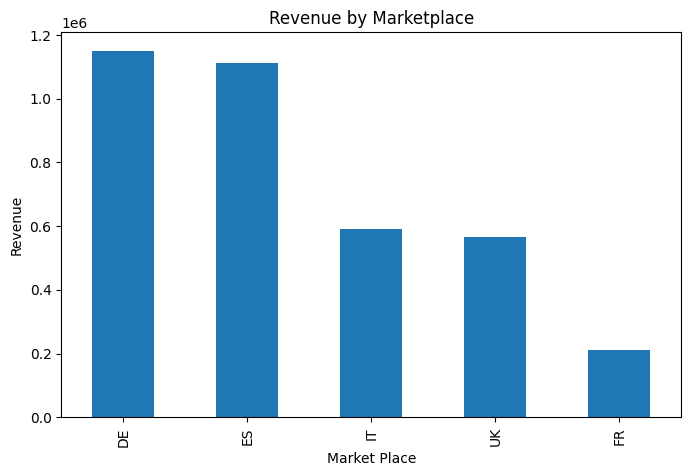

In [ ]:
plt.figure(figsize=(8,5))

revenue_market.plot(kind='bar')

plt.title("Revenue by Marketplace")
plt.ylabel("Revenue")

plt.show()

#### Analysis 2 — Order Volume Distribution

Analyze the distribution of orders to understand demand concentration by marketplace and period.


In [ ]:
orders_market = (
    df.groupby('Market Place')['Orders']
    .sum()
    .sort_values(ascending=False)
)

orders_market

,Orders
Market Place,
DE,45988
ES,45381
UK,27396
IT,23919
FR,8480


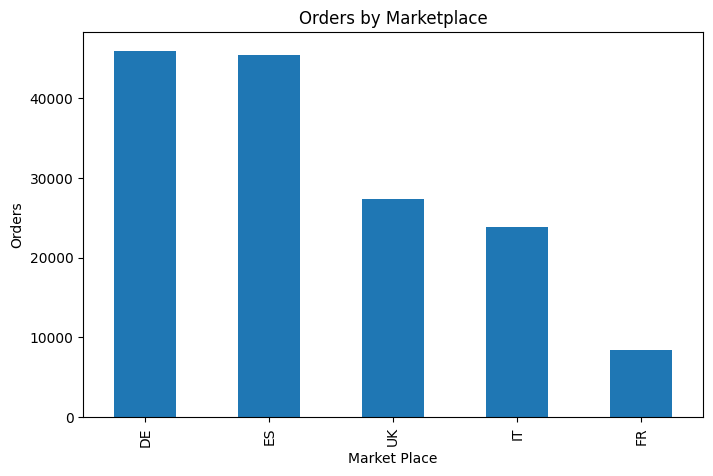

In [ ]:
plt.figure(figsize=(8,5))

orders_market.plot(kind='bar')

plt.title("Orders by Marketplace")
plt.ylabel("Orders")

plt.show()

#### Analysis 3 — Units Sold Distribution

Compare units sold alongside orders to compute the average units-per-order ratio and detect bulk-buy patterns.


In [ ]:
units_market = (
    df.groupby('Market Place')['Units']
    .sum()
    .sort_values(ascending=False)
)

units_market

,Units
Market Place,
DE,55390
ES,52445
UK,30880
IT,28012
FR,10450


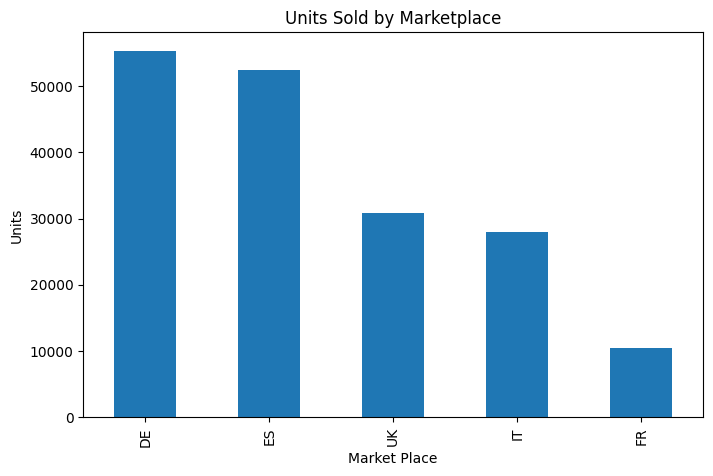

In [ ]:
plt.figure(figsize=(8,5))

units_market.plot(kind='bar')

plt.title("Units Sold by Marketplace")
plt.ylabel("Units")

plt.show()

#### Analysis 4 — Net Profit Distribution

Evaluate net profit contribution by marketplace. Marketplaces with high revenue but low profit signal cost inefficiency.


In [ ]:
profit_market = (
    df.groupby('Market Place')['Net Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_market

,Net Profit
Market Place,
DE,333395.70
ES,260852.48
IT,105717.83
UK,78125.58
FR,37598.64


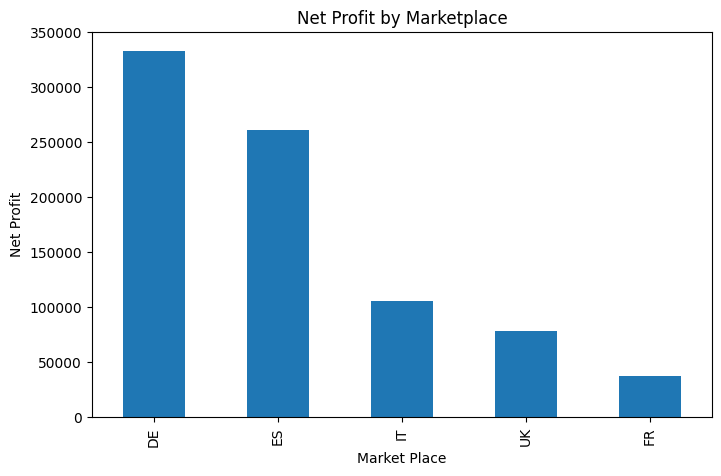

In [ ]:
plt.figure(figsize=(8,5))

profit_market.plot(kind='bar')

plt.title("Net Profit by Marketplace")
plt.ylabel("Net Profit")

plt.show()

#### Analysis 5 — Average Net Margin by Marketplace

Calculate and compare the blended net margin percentage per marketplace. This metric normalizes for scale and isolates pricing or cost structure differences.


In [ ]:
margin_market = (
    df.groupby('Market Place')['Net Margin']
    .mean()
    .sort_values(ascending=False)
)

margin_market

,Net Margin
Market Place,
UK,4.542503e+12
DE,2.439859e-01
ES,2.045839e-01
IT,1.117406e-01
FR,-3.436943e+12


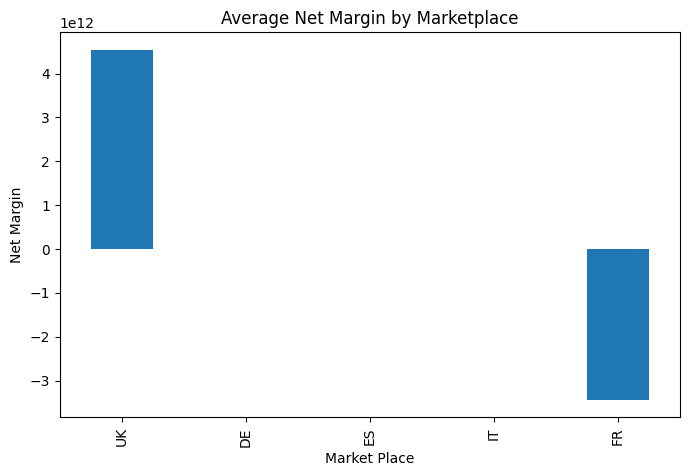

In [ ]:
plt.figure(figsize=(8,5))

margin_market.plot(kind='bar')

plt.title("Average Net Margin by Marketplace")
plt.ylabel("Net Margin")

plt.show()

#### Chart 1 — Revenue Contribution by Marketplace (Pie / Donut)

Visualize the proportional revenue contribution of each marketplace. Heavy concentration in a single market represents geographic risk.


In [ ]:
market_share = (
    df.groupby('Market Place')['Revenue']
    .sum()
)

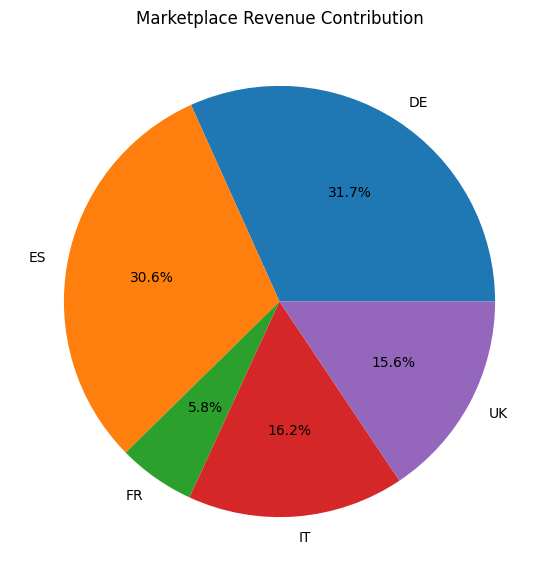

In [ ]:
plt.figure(figsize=(7,7))

market_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Marketplace Revenue Contribution")
plt.ylabel("")

plt.show()

#### Chart 2 — Revenue Trend Over Time (Line Chart)

Plot monthly aggregate revenue to identify growth trajectory, seasonal dips, and inflection points.


In [ ]:
monthly_revenue = (
    df.groupby(['Year','Month'])['Revenue']
    .sum()
)
monthly_revenue

Year  Month
2020  10       556418.12
      11       567418.18
      12       421130.36
2021  1        561266.13
      2        496282.89
      3        553953.23
      4        471664.86
Name: Revenue, dtype: float64

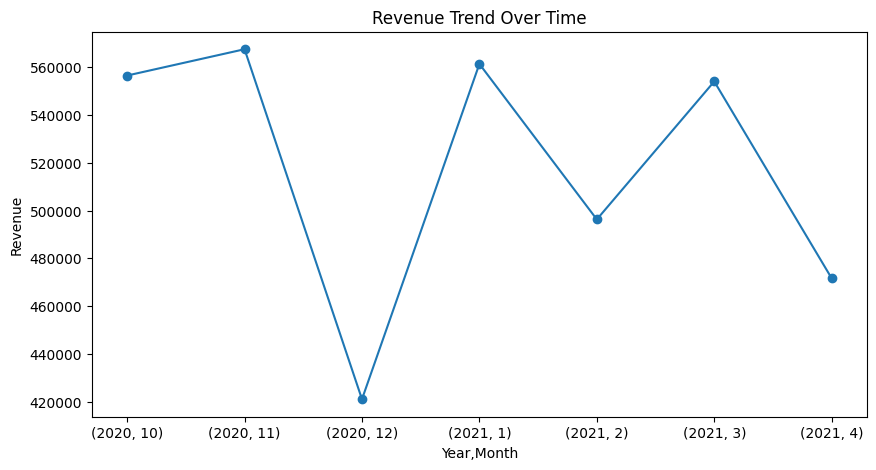

In [ ]:
monthly_revenue.plot(
    figsize=(10,5),
    marker='o'
)

plt.title("Revenue Trend Over Time")
plt.ylabel("Revenue")

plt.show()

#### Chart 3 — Best Performing Marketplace (Bar Chart)

Rank all marketplaces by total revenue to determine which account generates the highest top-line value.


In [ ]:
best_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .idxmax()
)

print("Best Marketplace =",best_market)

Best Marketplace = DE


#### Chart 4 — ROI by Marketplace

Compare average Net ROI across marketplaces. A marketplace with lower revenue but higher ROI may warrant increased investment.


In [ ]:
roi_market = (
    df.groupby('Market Place')['Net ROI']
    .mean()
    .sort_values(ascending=False)
)

roi_market

,Net ROI
Market Place,
DE,0.450536
ES,0.387646
UK,0.194663
FR,0.187562
IT,0.186036


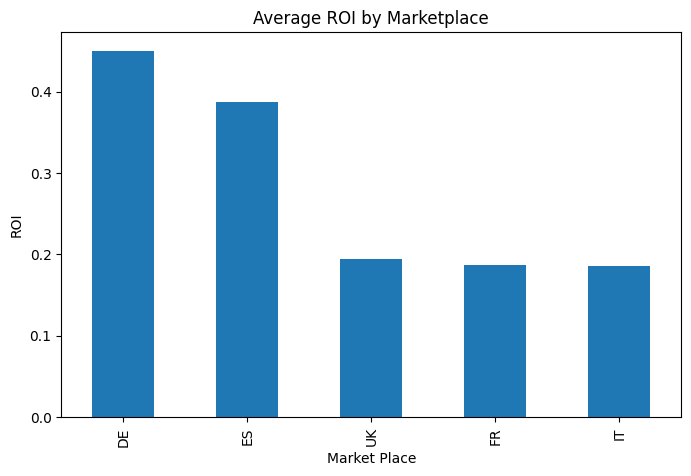

In [ ]:
plt.figure(figsize=(8,5))

roi_market.plot(kind='bar')

plt.title("Average ROI by Marketplace")
plt.ylabel("ROI")

plt.show()

#### Chart 5 — Multi-Marketplace Revenue Trend Over Time

Plot each marketplace as a separate line over the time axis. Diverging lines reveal which markets are growing, plateauing, or declining.


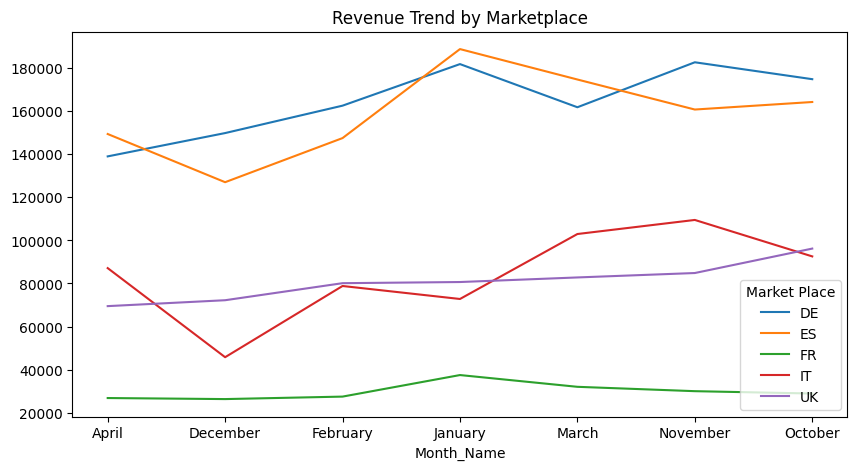

In [ ]:
trend = df.groupby(['Month_Name','Market Place'])['Revenue'].sum().unstack()
trend.plot(figsize=(10,5))
plt.title("Revenue Trend by Marketplace")
plt.show()

#### Chart 6 — Net Profit by Day of Week

Aggregate net profit by weekday to detect day-of-week patterns. Some categories see systematically stronger weekend or weekday performance.


In [ ]:
heatmap_data = df.pivot_table(
    values='Net Profit',
    index='Market Place',
    columns='Day_Name',
    aggfunc='sum'
)

heatmap_data

Day_Name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Market Place,,,,,,,
DE,41017.14,56244.78,39384.05,52741.96,46754.28,49452.73,47800.76
ES,32711.43,42986.97,31575.51,39874.20,37159.41,38887.31,37657.65
FR,4849.73,6102.18,4839.99,5527.20,5174.45,5507.14,5597.95
IT,12648.40,17838.11,13418.24,16332.39,15080.67,15340.25,15059.77
UK,11222.56,12583.94,10805.00,12117.46,11646.50,10164.45,9585.67


#### Chart 7 — Cost Breakdown by Marketplace (Stacked Bar)

Show the composition of costs (COGS, FBA Fees, PPC Cost, Taxes) for each marketplace as a stacked bar to identify where cost structure differs most across regions.


In [ ]:
costs = df.groupby('Market Place')[
    ['COGS','FBA Fees','PPC Cost','Net Profit']
].sum()

costs

,COGS,FBA Fees,PPC Cost,Net Profit
Market Place,,,,
DE,-302104.42,-323982.95,-59727.71,333395.70
ES,-318847.72,-326787.65,-70939.33,260852.48
FR,-62106.41,-75575.96,-12471.72,37598.64
IT,-170817.44,-193746.67,-32602.67,105717.83
UK,-216612.22,-172932.10,-27391.35,78125.58


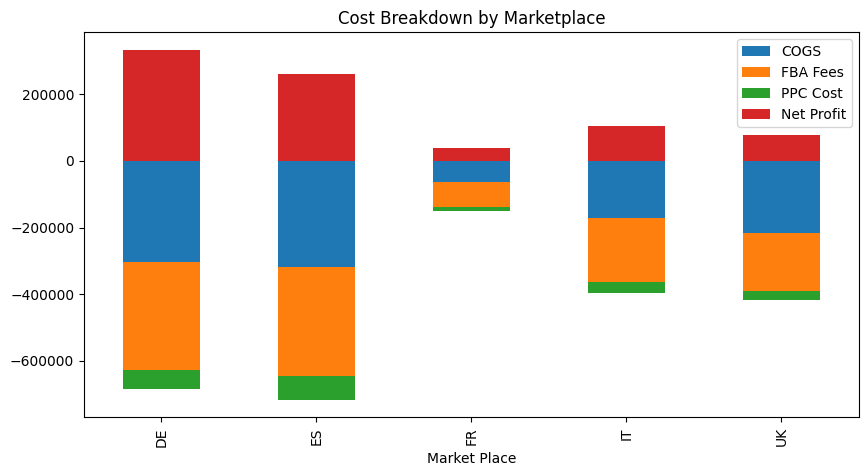

In [ ]:
costs.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Cost Breakdown by Marketplace")
plt.show()

---

## Dashboard 4 — Marketing & PPC Analysis

This section evaluates marketing efficiency across sessions, impressions, clicks, PPC spend, and conversion rates. Key analyses include the marketing funnel, traffic vs. conversion quadrants, the halo effect of PPC on organic sales, and marketplace-level PPC efficiency benchmarks.


### Libraries & Configuration
Load required libraries and set plotting style.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

### Data Source


> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


### Dataset Preparation

Select and validate the marketing-relevant columns from the pre-joined Star Schema table.


In [ ]:
df = fact.merge(product,on="Product_Key")
df = df.merge(market,on="Marketplace_Key")
df = df.merge(date,on="Date_Key")

### Dataset Overview

Inspect the shape, column types, and first few rows to confirm the dataset loaded correctly and the marketing columns are present.


In [ ]:
print("="*60)
print("Marketing Dataset Overview")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print("\nFirst 5 Rows")
display(df.head())

print("\nDataset Information")
df.info()

Marketing Dataset Overview
Dataset Shape : (13323, 48)

First 5 Rows


,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Account Title_y,Date,Day,Month,Month_Name,Quarter,Year,Week_Of_Year,Day_Name,Is_Weekend
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,[ UK ] Aava,2020-10-01,1,10,October,4,2020,40,Thursday,False
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,[ UK ] Aava,2020-10-02,2,10,October,4,2020,40,Friday,False
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,[ UK ] Aava,2020-10-03,3,10,October,4,2020,40,Saturday,True
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,[ UK ] Aava,2020-10-04,4,10,October,4,2020,40,Sunday,True
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,[ UK ] Aava,2020-10-05,5,10,October,4,2020,41,Monday,False



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 48 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title_x   13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          1

### Marketing Metrics — Descriptive Statistics

Generate summary statistics for the core marketing columns: Sessions, Clicks, Impressions, PPC Cost, PPC Sales, Organic Units, PPC Conversion Rate, and Unit Session %.


In [ ]:


marketing_cols = [
    "Sessions",
    "Clicks",
    "Impressions",
    "PPC Cost",
    "PPC Sales",
    "Organic Units",
    "PPC Conv",
    "Unit Session %"
]

stats = df[marketing_cols].describe().T

display(stats)

,count,mean,std,min,25%,50%,75%,max
Sessions,13323.0,20.968025,41.504721,0.00,0.00,0.0000,25.00,431.00
Clicks,13323.0,15.582376,25.220657,0.00,2.00,7.0000,18.00,713.00
Impressions,13323.0,4165.734819,6593.383509,0.00,537.00,1917.0000,5036.50,121882.00
PPC Cost,13323.0,-15.246775,26.139957,-1064.85,-17.23,-6.3300,-1.14,0.00
PPC Sales,13323.0,51.895073,94.217849,0.00,0.00,18.1700,63.61,2875.44
Organic Units,13323.0,13.284095,20.224256,0.00,3.00,7.0000,16.00,974.00
PPC Conv,13323.0,0.144013,0.258420,0.00,0.00,0.0769,0.20,6.00
Unit Session %,13323.0,0.134443,0.221282,0.00,0.00,0.0000,0.25,7.00


### KPI Calculations


#### KPI — Total Sessions

The total number of customer sessions recorded across all marketplaces and periods. Sessions represent potential purchase intent and are the top of the marketing funnel.


In [ ]:
total_sessions = df['Sessions'].sum()

print(f"Total Sessions: {total_sessions:,.0f}")

Total Sessions: 279,357


#### KPI — Average Click-Through Rate (CTR)

CTR = Total Clicks / Total Impressions × 100. A low CTR indicates poor ad creative relevance or targeting; a high CTR indicates strong keyword-to-product fit.


In [ ]:
avg_ctr = (
    df['Clicks'].sum() / df['Impressions'].sum() * 100
    if df['Impressions'].sum() != 0 else 0
)

print(f"Average CTR: {avg_ctr:.2f}%")

Average CTR: 0.37%


#### KPI — Total PPC Spend

Total advertising spend across all PPC campaigns. Viewed alongside PPC Sales, this determines overall campaign efficiency.


In [ ]:
total_ppc_spend = df['PPC Cost'].sum()

print(f"Total PPC Spend: ${total_ppc_spend:,.2f}")

Total PPC Spend: $-203,132.78


#### KPI — Total PPC Sales

Revenue directly attributed to PPC campaigns. Combined with PPC Cost, this is used to calculate ACoS (Advertising Cost of Sales).


In [ ]:
total_ppc_sales = df['PPC Sales'].sum()

print(f"Total PPC Sales: ${total_ppc_sales:,.2f}")

Total PPC Sales: $691,398.06


#### KPI — Average Conversion Rate (Unit Session %)

The percentage of sessions that result in a purchase. Low conversion rates with high traffic indicate a listing quality or pricing issue.


In [ ]:
avg_conversion_rate = df['Unit Session %'].mean()

print(f"Average Conversion Rate: {avg_conversion_rate:.2f}%")

Average Conversion Rate: 0.13%


### Correlation Analysis


#### Marketing Metrics Correlation Matrix

A heatmap of Pearson correlations between all key marketing variables. Strong positive correlations (e.g., Impressions → Clicks) are expected; unexpected correlations (e.g., PPC Cost inversely correlated with Organic Units) indicate the halo effect.


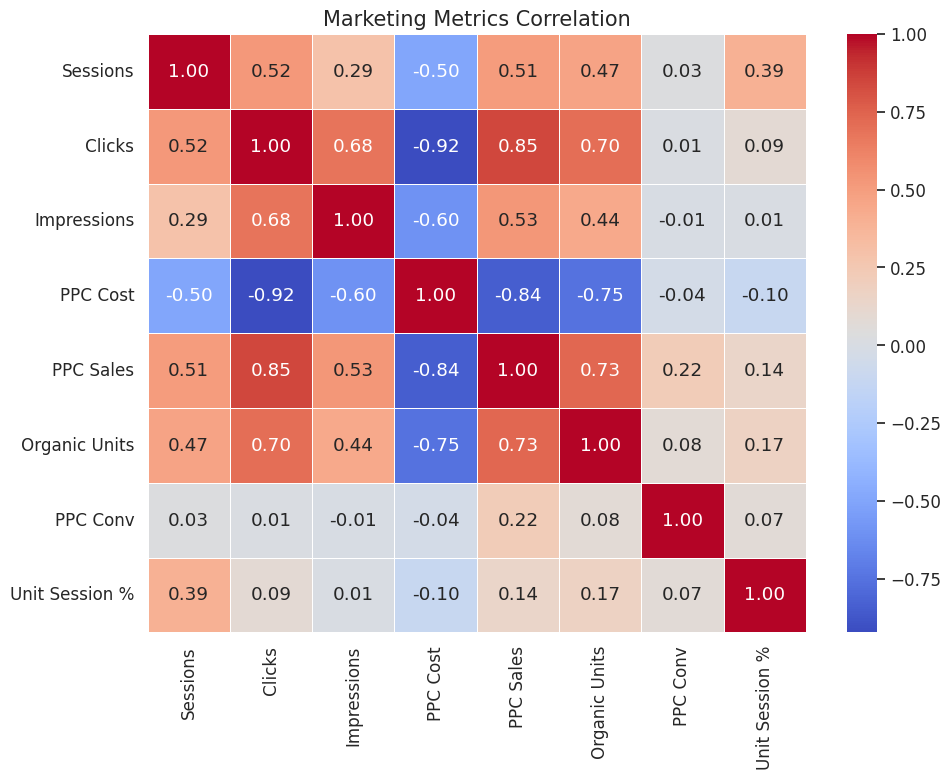

In [ ]:


plt.figure(figsize=(10,8))

corr = df[marketing_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Marketing Metrics Correlation", fontsize=15)

plt.tight_layout()

plt.show()

### Charts


#### Chart 1 — Top 10 Products by PPC Sales (Horizontal Bar)

Identify which SKUs generate the most PPC-attributed revenue. These are the products with the highest ad-driven demand and warrant careful bid management.


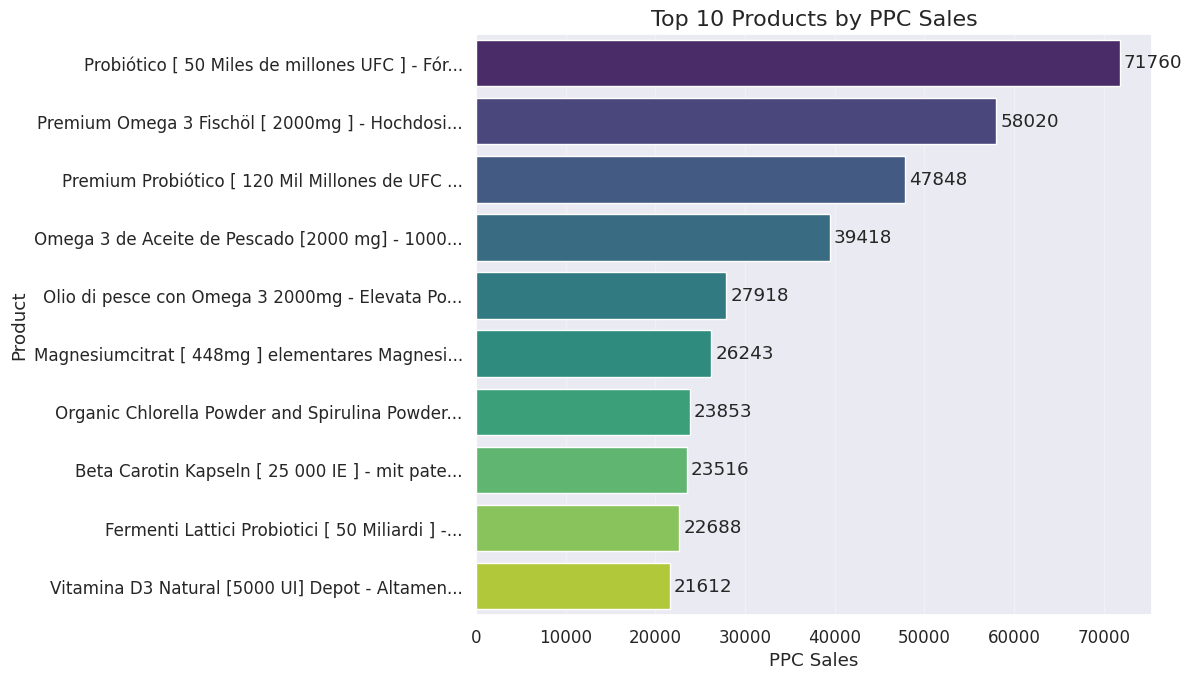

In [ ]:
top_products = (
    df.groupby("Title", as_index=False)["PPC Sales"]
      .sum()
      .sort_values(by="PPC Sales", ascending=False)
      .head(10)
)


top_products["Short Title"] = top_products["Title"].apply(
    lambda x: x[:45] + "..." if len(x) > 45 else x
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_products,
    x="PPC Sales",
    y="Short Title",
    hue="Short Title",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Top 10 Products by PPC Sales", fontsize=16)
plt.xlabel("PPC Sales")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

#### Chart 2 — Traffic vs. Conversion Quadrant Analysis (Scatter Plot)

Plot each SKU by Sessions (x-axis) against Unit Session % Conversion Rate (y-axis). The four quadrants reveal: **Stars** (high traffic, high conversion), **Wasted Spend** (high traffic, low conversion), **Hidden Gems** (low traffic, high conversion), and **Underperformers** (low on both).


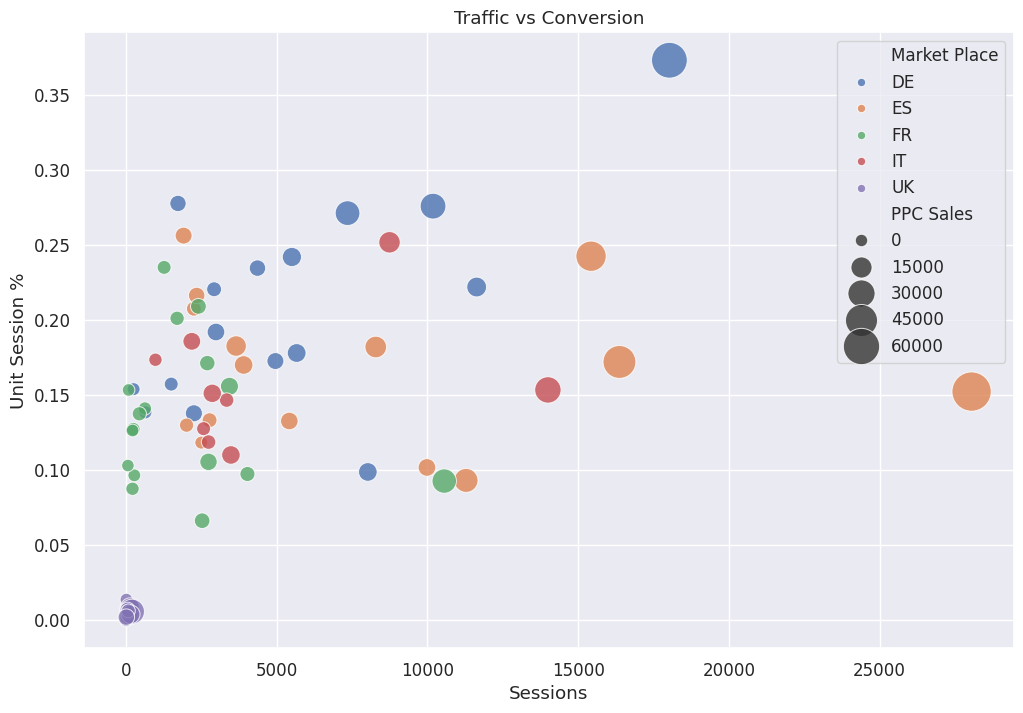

In [ ]:
traffic = df.groupby("SKU").agg({
    "Sessions":"sum",
    "Unit Session %":"mean",
    "PPC Sales":"sum",
    "Market Place":"first"
}).reset_index()

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=traffic,
    x="Sessions",
    y="Unit Session %",
    hue="Market Place",
    size="PPC Sales",
    sizes=(80,800),
    alpha=0.8
)

plt.title("Traffic vs Conversion")
plt.xlabel("Sessions")
plt.ylabel("Unit Session %")
plt.grid(True)

plt.show()

#### Chart 3 — Halo Effect: PPC Spend vs. Organic Units (Line Chart)

Examine whether increases in PPC spend correlate with growth in organic units sold — the "halo effect" where paid traffic improves organic rank and drives incremental organic sales.


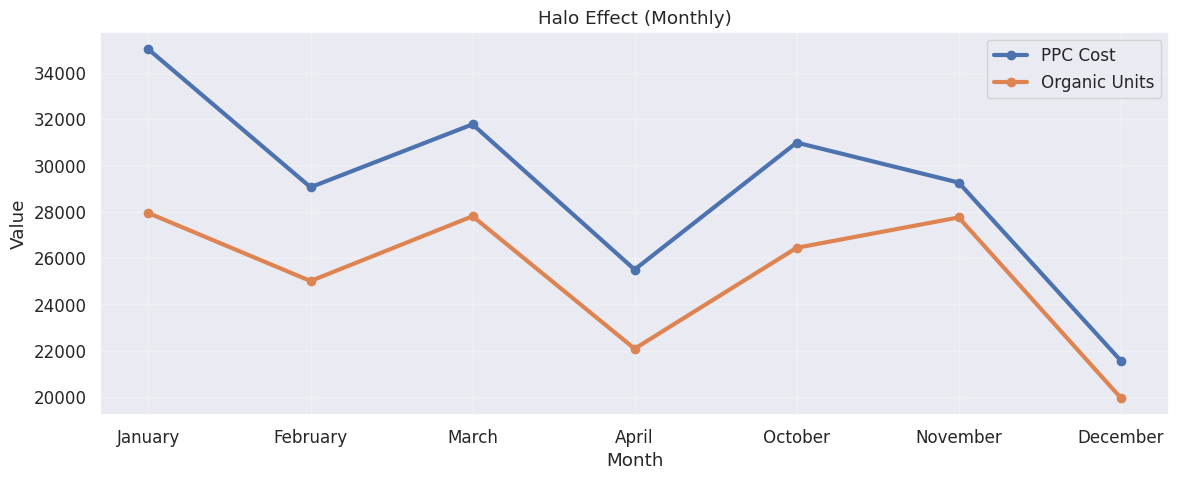

In [ ]:
halo = df.groupby("Month_Name").agg({
    "PPC Cost":"sum",
    "Organic Units":"sum"
}).reset_index()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

halo["Month_Name"] = pd.Categorical(
    halo["Month_Name"],
    categories=month_order,
    ordered=True
)

halo = halo.sort_values("Month_Name")

plt.figure(figsize=(12,5))

plt.plot(
    halo["Month_Name"],
    halo["PPC Cost"].abs(),
    marker="o",
    linewidth=3,
    label="PPC Cost"
)

plt.plot(
    halo["Month_Name"],
    halo["Organic Units"],
    marker="o",
    linewidth=3,
    label="Organic Units"
)

plt.title("Halo Effect (Monthly)")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Chart 4 — Marketing Funnel (Impressions → Clicks → Sessions → Orders)

Visualize drop-off at each stage of the customer acquisition funnel. Large gaps between stages pinpoint where the biggest optimization opportunities exist.


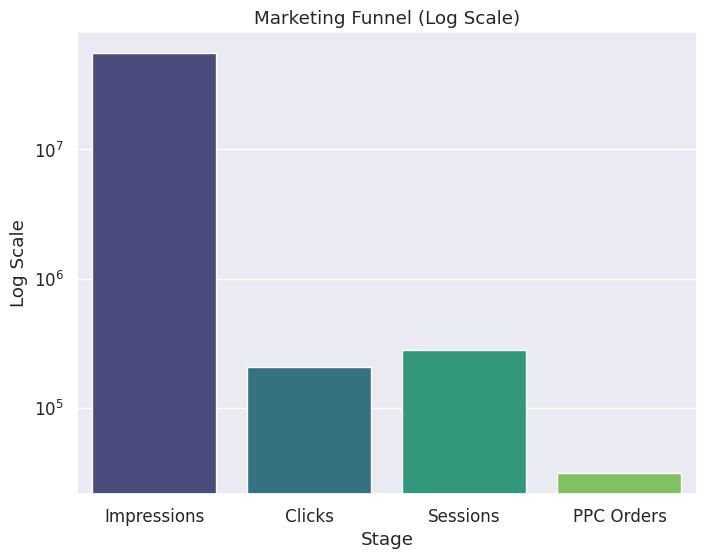

In [ ]:
funnel = pd.DataFrame({
    "Stage": ["Impressions", "Clicks", "Sessions", "PPC Orders"],
    "Value": [
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Sessions"].sum(),
        df["PPC Orders"].sum()
    ]
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=funnel,
    x="Stage",
    y="Value",
    hue="Stage",
    palette="viridis",
    legend=False
)

plt.yscale("log")
plt.title("Marketing Funnel (Log Scale)")
plt.ylabel("Log Scale")

plt.show()

#### Chart 5 — PPC Efficiency by Marketplace (Grouped Bar)

Compare PPC Cost and PPC Sales side-by-side for each marketplace. Marketplaces where PPC Sales significantly exceeds PPC Cost have efficient campaigns; the reverse indicates overspend.


<Figure size 1200x600 with 0 Axes>

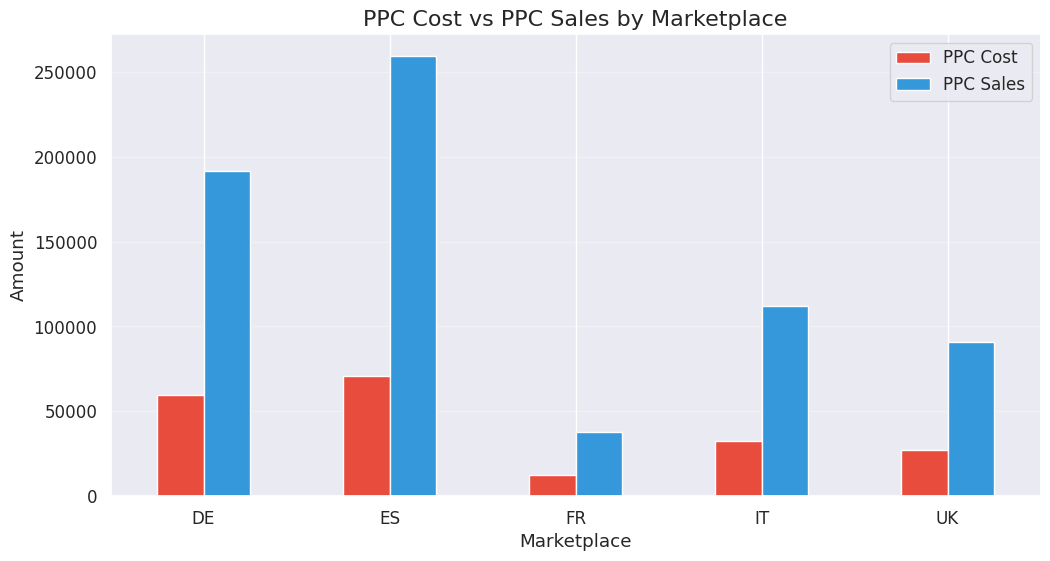

In [ ]:
marketplace = df.groupby("Market Place").agg({
    "PPC Cost":"sum",
    "PPC Sales":"sum"
}).reset_index()

marketplace["PPC Cost"] = marketplace["PPC Cost"].abs()

plt.figure(figsize=(12,6))

marketplace.plot(
    x="Market Place",
    y=["PPC Cost","PPC Sales"],
    kind="bar",
    figsize=(12,6),
    color=["#E74C3C","#3498DB"]
)

plt.title("PPC Cost vs PPC Sales by Marketplace", fontsize=16)
plt.xlabel("Marketplace")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Chart 6 — PPC Cost vs. PPC Conversion Rate by Marketplace (Dual Axis)

Overlay average PPC Cost (bars) with average PPC conversion rate (line) per marketplace. High cost with low conversion indicates poor keyword targeting or listing quality issues in that market.


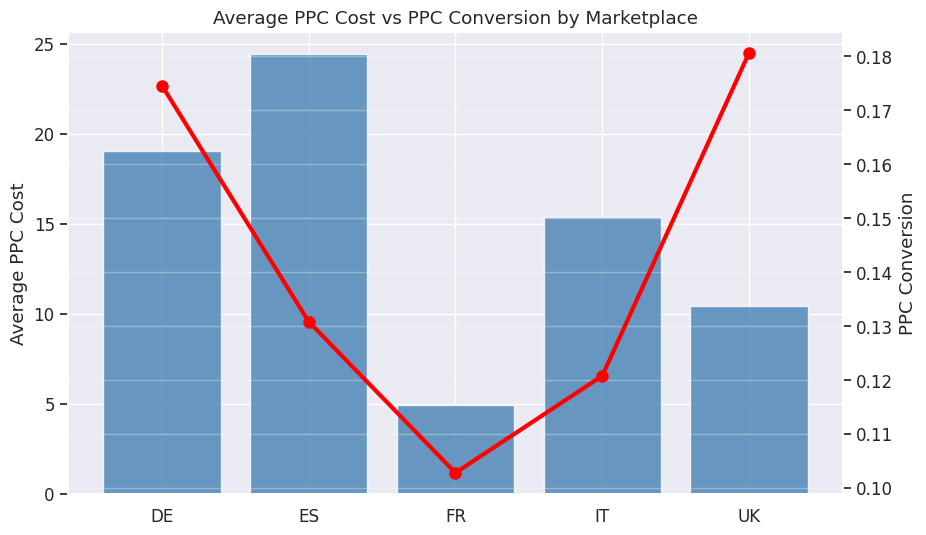

In [ ]:
trend = df.groupby("Market Place").agg({
    "PPC Cost":"mean",
    "PPC Conv":"mean"
}).reset_index()

trend["PPC Cost"] = trend["PPC Cost"].abs()

fig, ax1 = plt.subplots(figsize=(10,6))

bars = ax1.bar(
    trend["Market Place"],
    trend["PPC Cost"],
    color="steelblue",
    alpha=0.8,
    label="PPC Cost"
)

ax1.set_ylabel("Average PPC Cost")

ax2 = ax1.twinx()

ax2.plot(
    trend["Market Place"],
    trend["PPC Conv"],
    color="red",
    marker="o",
    linewidth=3,
    markersize=8,
    label="PPC Conversion"
)

ax2.set_ylabel("PPC Conversion")

plt.title("Average PPC Cost vs PPC Conversion by Marketplace")

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Chart 7 — PPC Sales Share by Marketplace (Pie Chart)

Show the proportion of total PPC-attributed revenue contributed by each marketplace. Comparing this distribution against the organic revenue distribution highlights where PPC is subsidizing performance.


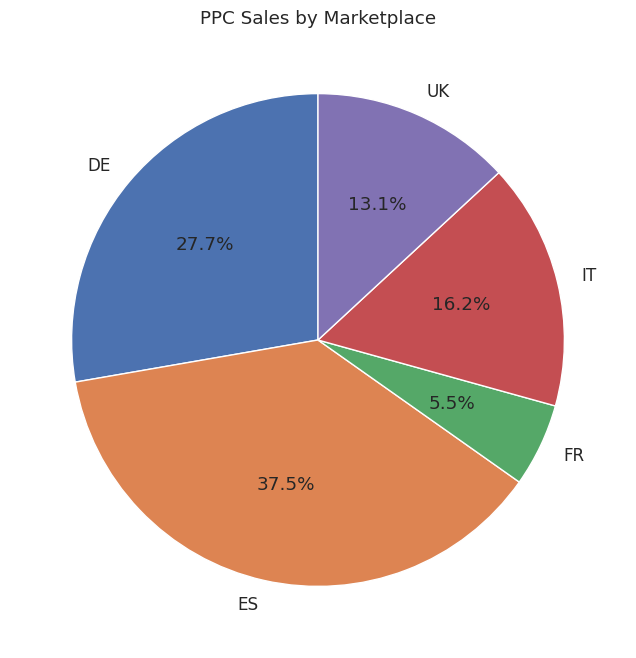

In [ ]:
market_share = df.groupby("Market Place")["PPC Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    market_share,
    labels=market_share.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("PPC Sales by Marketplace")

plt.show()

---

## Dashboard 5 — Refund Leakage & Quality Control

This section quantifies the financial impact of product returns. It identifies the worst-offending SKUs by refund rate, maps refund cost impact by marketplace, and examines the correlation between refund rates and net margin to surface quality control priorities.


### Libraries & Configuration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import plotly.express as px

### Data Source


> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


### Data Exploration

Inspect the loaded dataset for completeness. Verify that refund-related columns (`Refunded`, `Refund %`) are present and contain no unexpected nulls.


In [ ]:
fact_sales.head()

,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,Impressions,Clicks,PPC Orders,PPC Sales,PPC Cost,PPC Conv,OOE,Net Profit,Net Margin,Net ROI
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,3423,13,2,29.36,-13.06,0.1538,0,56.28,0.1852,0.3142
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,2786,7,0,0.00,-7.33,0.0000,0,71.73,0.2034,0.3439
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,2927,7,1,14.69,-6.15,0.1429,0,61.37,0.1386,0.2416
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,3584,16,2,44.07,-16.51,0.1250,0,39.49,0.1573,0.2684
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,4329,7,0,0.00,-4.47,0.0000,0,59.86,0.2116,0.3588


In [ ]:
dim_date.head()

,Date_Key,Date,Day,Month,Month_Name,Quarter,Year,Week_Of_Year,Day_Name,Is_Weekend
0,1,2020-10-01,1,10,October,4,2020,40,Thursday,False
1,2,2020-10-02,2,10,October,4,2020,40,Friday,False
2,3,2020-10-03,3,10,October,4,2020,40,Saturday,True
3,4,2020-10-04,4,10,October,4,2020,40,Sunday,True
4,5,2020-10-05,5,10,October,4,2020,41,Monday,False


In [ ]:
dim_product.head()

,Product_Key,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title
0,1,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...
1,2,UK_Aava_Omega_2000mg_120_05,X000JFSY57,B01GU9P0M2,No Parent,0,Aavalabs,Omega 3 2000mg Fish Oil Capsules - High Streng...
2,3,UK_Aava_Turmeric_1400mg_120_07,X000J6KEPJ,B01GU8L68A,No Parent,0,Aavalabs,Turmeric Curcumin Capsules with Black Pepper [...
3,4,FR_Aava_Turmeric_1400mg_180_01,X000UL0561,B07CXYM3H5,No Parent,0,Aavalabs,Gélules biodisponibles du complexe de curcumin...
4,5,FR_Aava_Magnesium_400mg_120_01,X000UL0OUX,B07CZ1P4BM,No Parent,0,Aavalabs,"Citrate de Magnésium - 1496 mg dont 448,8 mg d..."


In [ ]:
dim_market.head()

,Marketplace_Key,Market Place,Account Title
0,1,UK,[ UK ] Aava
1,2,FR,[ FR ] Aava
2,3,DE,[ DE ] Aava
3,4,IT,[ IT ] Aava
4,5,ES,[ ES ] Aava


In [ ]:
print(fact_sales.shape)
print(dim_date.shape)
print(dim_product.shape)
print(dim_market.shape)

(13323, 30)
(209, 10)
(102, 8)
(5, 3)


In [ ]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title     13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          13323 non-null  float6

In [ ]:
fact_sales.isnull().sum()

,0
Sales_Key,0
Date_Key,0
Marketplace_Key,0
Product_Key,0
Account Title,0
Taxes,0
Orders,0
Units,0
Refunded,0
Refund %,0


In [ ]:
fact_sales.describe()

,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Taxes,Orders,Units,Refunded,Refund %,Unit Session %,...,Impressions,Clicks,PPC Orders,PPC Sales,PPC Cost,PPC Conv,OOE,Net Profit,Net Margin,Net ROI
count,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,...,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.000000,13323.0,13323.000000,1.332300e+04,13323.000000
mean,6662.000000,106.820011,3.011409,50.032425,-21.696464,11.346093,13.298581,0.258650,0.017083,0.134443,...,4165.734819,15.582376,2.331757,51.895073,-15.246775,0.144013,0.0,61.224216,2.414762e+11,0.294288
std,3846.163153,60.476180,1.417455,30.231676,35.902825,16.978017,20.305648,1.237357,0.080636,0.221282,...,6593.383509,25.220657,4.106758,94.217849,26.139957,0.258420,0.0,110.080049,1.278643e+14,0.308586
min,1.000000,1.000000,1.000000,1.000000,-1168.650000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1064.850000,0.000000,0.0,-486.310000,-8.702340e+15,-2.940700
25%,3331.500000,54.000000,2.000000,26.000000,-25.190000,2.000000,3.000000,0.000000,0.000000,0.000000,...,537.000000,2.000000,0.000000,0.000000,-17.230000,0.000000,0.0,5.350000,7.945000e-02,0.115350
50%,6662.000000,108.000000,3.000000,48.000000,-9.460000,7.000000,8.000000,0.000000,0.000000,0.000000,...,1917.000000,7.000000,1.000000,18.170000,-6.330000,0.076900,0.0,24.960000,1.903000e-01,0.291900
75%,9992.500000,160.000000,4.000000,80.000000,-1.980000,14.000000,16.000000,0.000000,0.000000,0.250000,...,5036.500000,18.000000,3.000000,63.610000,-1.140000,0.200000,0.0,65.095000,2.651000e-01,0.439600
max,13323.000000,209.000000,5.000000,102.000000,0.000000,955.000000,975.000000,42.000000,1.055600,7.000000,...,121882.000000,713.000000,135.000000,2875.440000,0.000000,6.000000,0.0,2342.190000,1.191953e+16,2.695400


In [ ]:
dim_date.columns.tolist()

['Date_Key',
 'Date',
 'Day',
 'Month',
 'Month_Name',
 'Quarter',
 'Year',
 'Week_Of_Year',
 'Day_Name',
 'Is_Weekend']

### Dataset Preparation

Derive the refund cost impact metric: the estimated revenue lost due to returned units.


In [ ]:
sales = fact_sales.merge(
    dim_date,
    on='Date_Key',
    how='left'
)

sales = sales.merge(
    dim_product,
    on='Product_Key',
    how='left'
)

sales = sales.merge(
    dim_market,
    on='Marketplace_Key',
    how='left'
)

sales.head()

,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Is_Weekend,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title_y
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,True,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,True,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava


In [ ]:
sales.shape

(13323, 48)

In [ ]:
sales.columns.tolist()

['Sales_Key',
 'Date_Key',
 'Marketplace_Key',
 'Product_Key',
 'Account Title_x',
 'Taxes',
 'Orders',
 'Units',
 'Refunded',
 'Refund %',
 'Unit Session %',
 'Promo Units',
 'Organic Units',
 'Per Unit Revenue',
 'Revenue',
 'COGS',
 'FBA Fees',
 'Promo Amount',
 'Sessions',
 'Page Views',
 'Impressions',
 'Clicks',
 'PPC Orders',
 'PPC Sales',
 'PPC Cost',
 'PPC Conv',
 'OOE',
 'Net Profit',
 'Net Margin',
 'Net ROI',
 'Date',
 'Day',
 'Month',
 'Month_Name',
 'Quarter',
 'Year',
 'Week_Of_Year',
 'Day_Name',
 'Is_Weekend',
 'SKU',
 'FNSKU',
 'ASIN',
 'Parent ASIN',
 'Is Parent',
 'Brand',
 'Title',
 'Market Place',
 'Account Title_y']

In [ ]:
sales['Year'].value_counts()

,count
Year,
2021,7623
2020,5700


### KPI Calculations


#### KPI 1 — Total Refunded Units

The aggregate count of units returned by customers across all SKUs and marketplaces. This is the primary volume measure of return activity.


In [ ]:
total_refunded = sales['Refunded'].sum()
total_refunded

np.int64(3446)

#### KPI 2 — Blended Refund Rate

Average refund rate across all rows (Refunded Units / Units Sold × 100). Industry benchmarks for Amazon FBA typically sit between 2–5%; rates above 8% signal quality problems.


In [ ]:
refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

print(f"Refund Rate: {refund_rate:.2f}%")

Refund Rate: 1.94%


#### KPI 3 — High-Risk SKU Count

Number of SKUs with a refund rate above a defined threshold (e.g., 10%). These products require immediate quality investigation or listing review.


In [ ]:
sku_refund = sales.groupby('SKU').agg({
    'Refunded':'sum',
    'Units':'sum'
})

sku_refund['Refund_Rate'] = (
    sku_refund['Refunded'] /
    sku_refund['Units']
) * 100

avg_refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

high_risk_skus = (
    sku_refund['Refund_Rate'] > avg_refund_rate
).sum()

print(high_risk_skus)

18


#### KPI 4 — Revenue Lost Due to Refunds

Estimated revenue leakage: Refunded Units × Per Unit Revenue. This quantifies the direct top-line impact of returns, separate from refund processing costs.


In [ ]:
sales['Revenue_Lost'] = (
    sales['Refunded'] *
    sales['Per Unit Revenue']
)

revenue_lost = sales['Revenue_Lost'].sum()

print(f"${revenue_lost:,.2f}")

$109,521.69


##5 - Revenue Lost per Marketplace

In [ ]:
sales['Refund_Cost_Impact'] = (
    sales['Refunded'].fillna(0) *
    sales['Per Unit Revenue'].fillna(0)
)

market_revenue_lost = sales.groupby(
    'Market Place', as_index=False
)['Refund_Cost_Impact'].sum()

market_revenue_lost = market_revenue_lost.sort_values(
    'Refund_Cost_Impact',
    ascending=False
)

print(market_revenue_lost.to_string(index=False))

##6 - Refund-to-Net Profit Ratio

In [ ]:
total_net_profit = sales['Net Profit'].sum()

refund_to_profit_ratio = (
    revenue_lost / total_net_profit
) * 100

print(f"Refund-to-Net Profit Ratio: {refund_to_profit_ratio:.2f}%")

### Charts


#### Data Preparation for Visualization

Aggregate refund metrics by time period and by SKU to prepare the datasets needed for the charts below.


In [ ]:
sales['Refund_Cost_Impact'] = (
    sales['Refunded'] *
    sales['Per Unit Revenue']
)

monthly_refund = sales.groupby(
    ['Year', 'Month', 'Month_Name'],
    as_index=False
)['Refund_Cost_Impact'].sum()

monthly_refund = monthly_refund.sort_values(
    ['Year', 'Month']
)

monthly_refund['Month_Year'] = (
    monthly_refund['Month_Name']
    + '-'
    + monthly_refund['Year'].astype(str)
)

#### Chart 1 — Financial Impact of Refunds Over Time (Area Chart)

Plot the monthly refund cost impact as a shaded area chart. Rising areas indicate growing return rates or increasing per-unit values being returned.


In [ ]:
import pandas as pd
import plotly.express as px

sales['Refund_Cost_Impact'] = (
    sales['Refunded'].fillna(0) *
    sales['Per Unit Revenue'].fillna(0)
)

monthly_refund = sales.groupby(
    ['Year', 'Month'],
    as_index=False
)['Refund_Cost_Impact'].sum()

monthly_refund = monthly_refund.sort_values(['Year', 'Month'])

monthly_refund['Month_Year'] = pd.to_datetime(
    monthly_refund['Year'].astype(str) + '-' +
    monthly_refund['Month'].astype(str) + '-01'
)

fig = px.area(
    monthly_refund,
    x='Month_Year',
    y='Refund_Cost_Impact',
    markers=True,
    title='Financial Impact of Refunds Over Time',
    labels={
        'Month_Year': 'Month',
        'Refund_Cost_Impact': 'Revenue Lost Due to Refunds ($)'
    }
)

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    hovermode='x unified',
    height=600
)

fig.update_traces(
    hovertemplate='Date: %{x|%Y-%m}<br>Refund Loss: $%{y:,.2f}'
)

fig.show()

#### Chart 2 — Worst Offenders: Refund Rate by SKU (Horizontal Bar)

Rank the top offending SKUs by refund rate. These products should be prioritized for product quality audits, listing copy reviews, and size/fit accuracy improvements.


In [ ]:
import pandas as pd
import plotly.express as px

sku_refund = sales.groupby('SKU', as_index=False).agg({
    'Refunded': 'sum',
    'Units': 'sum'
})

sku_refund['Refund_Rate'] = (
    sku_refund['Refunded'] / sku_refund['Units']
).fillna(0) * 100

top_refund_skus = sku_refund.sort_values(
    'Refund_Rate',
    ascending=False
).head(10)

avg_refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

fig = px.bar(
    top_refund_skus,
    x='Refund_Rate',
    y='SKU',
    orientation='h',
    title='Worst Offenders: Refund % by SKU',
    labels={
        'Refund_Rate': 'Refund Rate (%)',
        'SKU': 'SKU'
    }
)

fig.add_vline(
    x=avg_refund_rate,
    line_dash='dash',
    annotation_text=f'Average = {avg_refund_rate:.2f}%',
    annotation_position='top'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=600,
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

#### Chart 3 — Refund Rate vs. Net Margin Correlation (Scatter Plot)

Plot each SKU by its refund rate (x-axis) against its net margin percentage (y-axis). A negative correlation confirms that high refund rates are a direct driver of margin erosion. Outliers above the trend line are products that maintain margin despite returns (strong pricing power).


In [ ]:
sku_margin = sales.groupby('SKU').agg({
    'Refunded':'sum',
    'Units':'sum',
    'Net Profit':'sum',
    'Revenue':'sum'
}).reset_index()

sku_margin['Refund_Rate'] = (
    sku_margin['Refunded'] /
    sku_margin['Units']
) * 100

sku_margin['Net_Margin_Pct'] = (
    sku_margin['Net Profit'] /
    sku_margin['Revenue']
) * 100

In [ ]:
sku_margin = sku_margin[
    sku_margin['Units'] >= 100
]

In [ ]:
import plotly.express as px

fig = px.scatter(
    sku_margin,
    x='Refund_Rate',
    y='Net_Margin_Pct',
    hover_data=['SKU'],
    title='Refund Rate vs Net Margin'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    xaxis_title='Refund Rate (%)',
    yaxis_title='Net Margin (%)',
    height=600
)

fig.show()

#### Chart 4 — Refund Cost Impact by Marketplace (Bar Chart)

Summarize total refund cost impact per marketplace. A marketplace with disproportionately high refund cost relative to revenue may have listing translation issues, size expectation mismatches, or logistics quality problems.


In [ ]:
market_refund = sales.groupby('Market Place', as_index=False)[
    'Refund_Cost_Impact'
].sum()

market_refund = market_refund.sort_values(
    'Refund_Cost_Impact',
    ascending=False
)

In [ ]:
fig = px.bar(
    market_refund,
    x='Market Place',
    y='Refund_Cost_Impact',
    title='Refund Cost Impact by Marketplace'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()

##
Chart 5: Refund Trend by Marketplace (Line Chart)

In [ ]:
market_monthly = sales.groupby(
    ['Year', 'Month', 'Market Place'],
    as_index=False
).agg(
    Refunded=('Refunded', 'sum'),
    Units=('Units', 'sum')
)

market_monthly['Refund_Rate'] = (
    market_monthly['Refunded'] /
    market_monthly['Units'].replace(0, np.nan)
).fillna(0) * 100

market_monthly['Date'] = pd.to_datetime(
    market_monthly['Year'].astype(str) + '-' +
    market_monthly['Month'].astype(str) + '-01'
)

market_monthly = market_monthly.sort_values('Date')

fig = px.line(
    market_monthly,
    x='Date',
    y='Refund_Rate',
    color='Market Place',
    markers=True,
    title='Refund Trend by Marketplace',
    labels={
        'Date': 'Month',
        'Refund_Rate': 'Refund Rate (%)',
        'Market Place': 'Marketplace'
    }
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    hovermode='x unified',
    height=600,
    legend=dict(orientation='h', y=-0.2)
)

fig.show()

---

## Dashboard 6 — Promotions & Returns Analysis

This section analyzes the effectiveness of promotional spending. It compares promo vs. organic unit splits, tracks promotional spend trends over time, identifies the top products by promo units, and examines the relationship between promo spend and refund rates.


### Data Source


> **Data source:** All charts and tables in this section use the `df` DataFrame loaded in Section 0 from the Gold Layer Star Schema output. No additional loading or joining is needed.


In [ ]:
# Build one denormalized analysis table (Fact + all Dims joined)
# This is the equivalent of the "Model View" relationships we will build in Power BI

df = (
    fact_sales
    .merge(dim_date, on='Date_Key', how='left')
    .merge(dim_product, on='Product_Key', how='left')
    .merge(dim_account_market, on='Account_Market_Key', how='left')
)

print('Joined analysis table shape:', df.shape)
df.head(3)

Joined analysis table shape: (13323, 46)


,Date_Key,Product_Key,Account_Market_Key,Taxes,Orders,Units,Refunded,Refund %,Unit Session %,Promo Units,...,Is_Weekend,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title
0,1,1,1,-50.34,17,17,0,0.00,0.00,0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
1,2,1,1,-58.89,20,20,0,0.00,0.00,0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
2,3,1,1,-72.41,18,24,0,0.00,0.00,0,...,True,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava


### Dashboard 6 Overview

This section analyses the effectiveness of Amazon promotional campaigns. Key questions: Does promotional spend drive incremental volume, or does it cannibalize organic sales? Are high-promo products also high-refund products?

**KPIs tracked:**
- Total Promo Units sold under promotional pricing
- Total Promo Amount spent on promotions
- Total Refunded Units during the same period
- Average Refund % across promoted products


In [ ]:
# --- KPI Cards ---
total_promo_units = df['Promo Units'].sum()
total_promo_amount = df['Promo Amount'].sum()
total_refunded_units = df['Refunded'].sum()
avg_refund_pct = df['Refund %'].mean()

print(f"Total Promo Units:      {total_promo_units:,.0f}")
print(f"Total Promo Amount:     ${total_promo_amount:,.2f}")
print(f"Total Refunded Units:    {total_refunded_units:,.0f}")
print(f"Average Refund %:        {avg_refund_pct:.2%}")

Total Promo Units:      193
Total Promo Amount:     $-156,765.64
Total Refunded Units:    3,446
Average Refund %:        1.71%


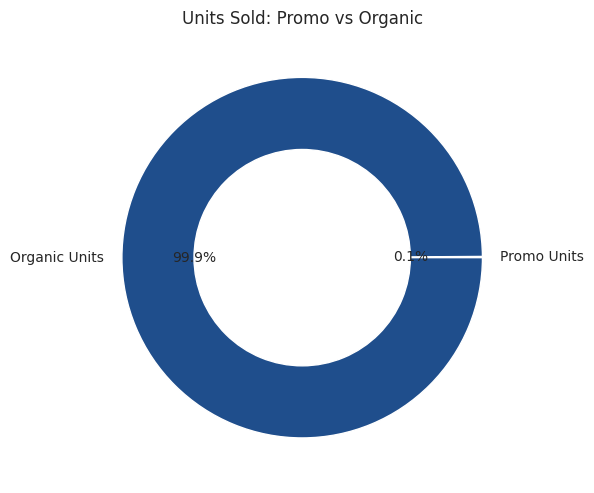

In [ ]:
# Q1: Promo vs Organic Units Share -> Donut Chart
units_split = pd.DataFrame({
    'Type': ['Promo Units', 'Organic Units'],
    'Units': [df['Promo Units'].sum(), df['Organic Units'].sum()]
})

plt.figure(figsize=(6, 6))
plt.pie(units_split['Units'], labels=units_split['Type'], autopct='%1.1f%%',
        colors=['#e07b39', '#1f4e8c'], wedgeprops={'width': 0.4})
plt.title('Units Sold: Promo vs Organic')
plt.tight_layout()
plt.show()

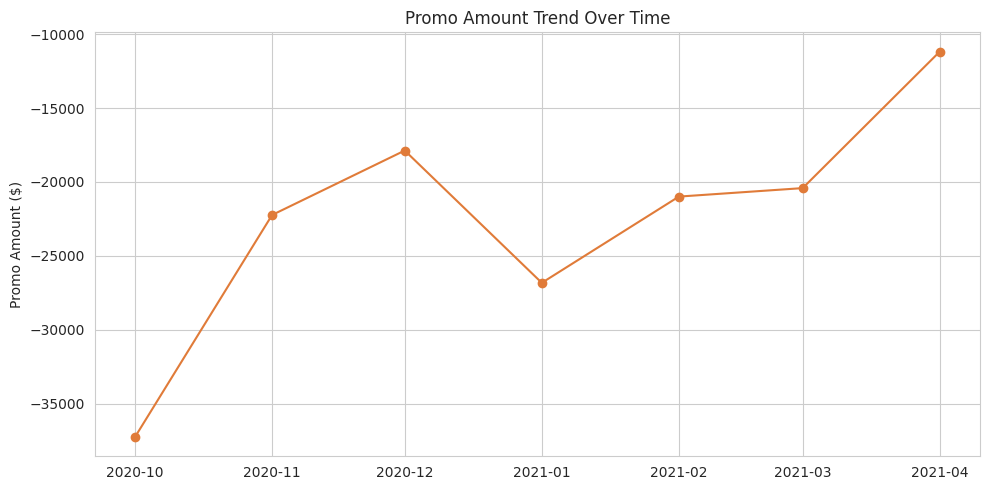

In [ ]:
# Q2: Promo Spend Trend Over Time -> Line Chart
promo_trend = df.groupby(['Year', 'Month'], as_index=False).agg(Promo_Amount=('Promo Amount', 'sum'))
promo_trend['Period'] = pd.to_datetime(promo_trend[['Year', 'Month']].assign(DAY=1))
promo_trend = promo_trend.sort_values('Period')

plt.figure()
plt.plot(promo_trend['Period'], promo_trend['Promo_Amount'], marker='o', color='#e07b39')
plt.title('Promo Amount Trend Over Time')
plt.ylabel('Promo Amount ($)')
plt.tight_layout()
plt.show()

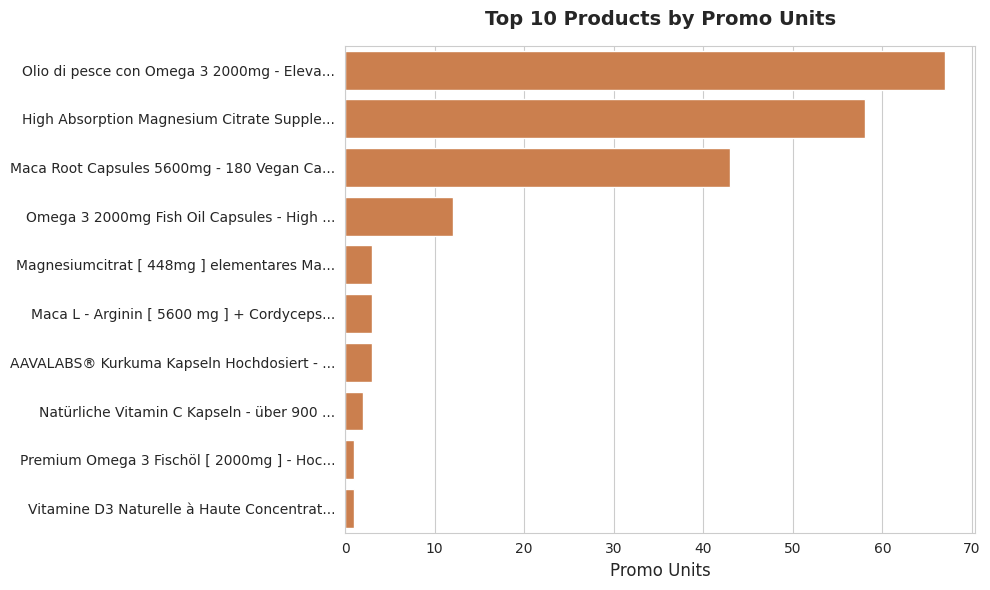

In [ ]:
# Q3: Top 10 Products by Promo Units -> Horizontal Bar Chart
top10_promo = df.groupby('Title', as_index=False).agg(Promo_Units=('Promo Units', 'sum')).sort_values('Promo_Units', ascending=False).head(10)
top10_promo['Short_Title'] = top10_promo['Title'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_promo, y='Short_Title', x='Promo_Units', color='#e07b39')
plt.title('Top 10 Products by Promo Units', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Promo Units', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

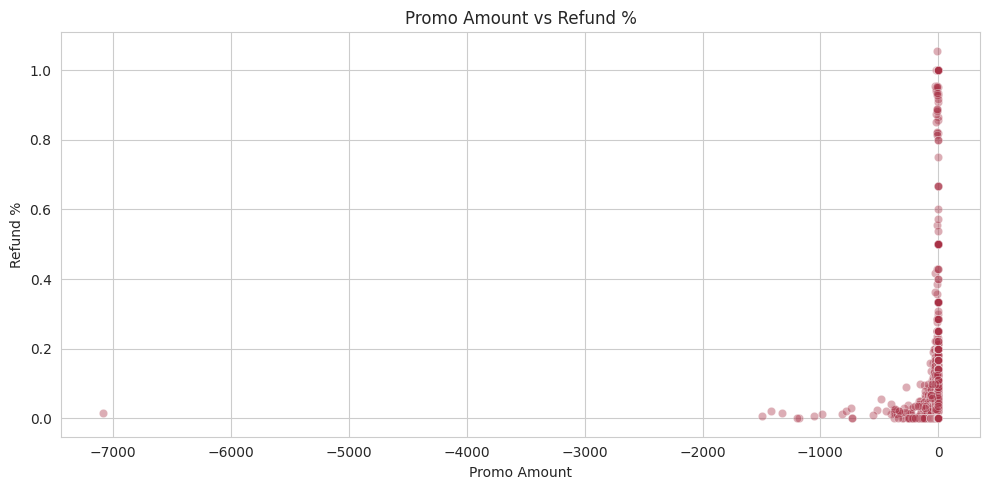

In [ ]:
# Q4: Promo Amount vs Refund % -> Scatter Plot
plt.figure()
sns.scatterplot(data=df, x='Promo Amount', y='Refund %', alpha=0.4, color='#a83246')
plt.title('Promo Amount vs Refund %')
plt.tight_layout()
plt.show()